<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/akshyat_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/akshyat_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


2.3 Monolingual vs Multilingual  
COM3029 NLP Group Coursework


In [1]:
!pip install transformers datasets peft scikit-learn accelerate


In [2]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, load_dataset
from peft import LoraConfig, PeftModel, get_peft_model
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

runs_to_try = [42, 1234]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mono_model_name = "meta-llama/Llama-3.2-1B"
multi_model_name = "xlm-roberta-base"


def lock_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)


print("device:", device)
print("mono model:", mono_model_name)
print("multi model:", multi_model_name)


device: cuda
mono model: meta-llama/Llama-3.2-1B
multi model: xlm-roberta-base


In [3]:
# llama needs the usual hf approval + token setup in colab
# leaving this here so the notebook still runs end to end if needed
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))


In [4]:
# get the coursework dataset and keep the splits
raw_ds = load_dataset("surrey-nlp/BESSTIE-CW-26")

train_df = raw_ds["train"].to_pandas()
valid_df = raw_ds["validation"].to_pandas()
test_df = raw_ds["test"].to_pandas()

for split_df in [train_df, valid_df, test_df]:
    split_df["Sarcasm"] = split_df["Sarcasm"].astype(int)


# per-variety splits for the adapter runs
train_au = train_df[train_df["variety"] == "en-AU"].reset_index(drop=True)
train_uk = train_df[train_df["variety"] == "en-UK"].reset_index(drop=True)
train_in = train_df[train_df["variety"] == "en-IN"].reset_index(drop=True)

valid_au = valid_df[valid_df["variety"] == "en-AU"].reset_index(drop=True)
valid_uk = valid_df[valid_df["variety"] == "en-UK"].reset_index(drop=True)
valid_in = valid_df[valid_df["variety"] == "en-IN"].reset_index(drop=True)

test_au = test_df[test_df["variety"] == "en-AU"].reset_index(drop=True)
test_uk = test_df[test_df["variety"] == "en-UK"].reset_index(drop=True)
test_in = test_df[test_df["variety"] == "en-IN"].reset_index(drop=True)

# pooled version for xlm-r
train_all = train_df.reset_index(drop=True)
valid_all = valid_df.reset_index(drop=True)

print("train sizes")
print("en-AU:", len(train_au))
print("en-UK:", len(train_uk))
print("en-IN:", len(train_in))
print("pooled:", len(train_all))

print("label mix in training split")
for label_name, frame in [("en-AU", train_au), ("en-UK", train_uk), ("en-IN", train_in)]:
    counts = frame["Sarcasm"].value_counts()
    print(label_name, "-> not sarcastic:", counts.get(0, 0), "sarcastic:", counts.get(1, 0))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

train sizes
en-AU: 1145
en-UK: 1203
en-IN: 1399
pooled: 3747
label mix in training split
en-AU -> not sarcastic: 808 sarcastic: 337
en-UK -> not sarcastic: 1111 sarcastic: 92
en-IN -> not sarcastic: 1304 sarcastic: 95


In [5]:
# small utility bits used all the way through

def prep_split(frame, tokenizer):
    mini = frame[["text", "Sarcasm"]].rename(columns={"Sarcasm": "labels"})
    ds_part = Dataset.from_pandas(mini)

    def tok_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=128)

    ds_part = ds_part.map(tok_batch, batched=True)
    ds_part = ds_part.remove_columns(["text"])
    ds_part.set_format("torch")
    return ds_part


# coursework metric

def get_macro_f1(eval_pred):
    raw_preds, gold = eval_pred
    picked = np.argmax(raw_preds, axis=-1)
    return {"macro_f1": f1_score(gold, picked, average="macro")}


print("prep + metric bits ready")


prep + metric bits ready


In [6]:
# same lora setup each time, so keeping it in one place
adapter_setup = LoraConfig(
    task_type="SEQ_CLS",
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
)

print("lora config ready")


lora config ready


Monolingual: LLaMA-3.2-1B + LoRA


In [7]:
def run_one_adapter(train_part, valid_part, split_name, seed_value=42):
    lock_seed(seed_value)

    print()
    print("running adapter for", split_name, "| seed", seed_value)

    tok = AutoTokenizer.from_pretrained(mono_model_name)
    tok.pad_token = tok.eos_token

    train_ds = prep_split(train_part, tok)
    valid_ds = prep_split(valid_part, tok)

    base = AutoModelForSequenceClassification.from_pretrained(
        mono_model_name,
        num_labels=2,
        dtype=torch.float16,
    )
    base.config.pad_token_id = tok.eos_token_id

    model = get_peft_model(base, adapter_setup)
    model.print_trainable_parameters()
    model.to(device)

    folder_name = f"adapter_{split_name}_seed{seed_value}"

    args = TrainingArguments(
        output_dir=folder_name,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=0.0002,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=False,
        seed=seed_value,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        processing_class=tok,
        data_collator=DataCollatorWithPadding(tok),
        compute_metrics=get_macro_f1,
    )

    trainer.train()

    model.save_pretrained(folder_name)
    tok.save_pretrained(folder_name)

    print("saved to", folder_name)
    return folder_name


print("adapter training function ready")


adapter training function ready


In [8]:
#  Australian
adapter_au_1 = run_one_adapter(train_au, valid_au, "en-AU", seed_value=runs_to_try[0])
adapter_au_2 = run_one_adapter(train_au, valid_au, "en-AU", seed_value=runs_to_try[1])



running adapter for en-AU | seed 42


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 856,064 || all params: 1,236,674,560 || trainable%: 0.0692


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.543945,0.732051
2,No log,0.615723,0.761905
3,No log,0.726562,0.721482


saved to adapter_en-AU_seed1234


In [9]:
# UK
adapter_uk_1 = run_one_adapter(train_uk, valid_uk, "en-UK", seed_value=runs_to_try[0])
adapter_uk_2 = run_one_adapter(train_uk, valid_uk, "en-UK", seed_value=runs_to_try[1])



running adapter for en-UK | seed 42


Map:   0%|          | 0/1203 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 856,064 || all params: 1,236,674,560 || trainable%: 0.0692


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.292969,0.479381
2,No log,0.170654,0.712251
3,No log,0.141724,0.796371


saved to adapter_en-UK_seed1234


In [10]:
# indian
adapter_in_1 = run_one_adapter(train_in, valid_in, "en-IN", seed_value=runs_to_try[0])
adapter_in_2 = run_one_adapter(train_in, valid_in, "en-IN", seed_value=runs_to_try[1])



running adapter for en-IN | seed 42


Map:   0%|          | 0/1399 [00:00<?, ? examples/s]

Map:   0%|          | 0/117 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 856,064 || all params: 1,236,674,560 || trainable%: 0.0692


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.345703,0.595556
2,No log,0.250488,0.570730
3,0.226538,0.279785,0.582143


saved to adapter_en-IN_seed1234


In [11]:
def score_saved_adapter(adapter_folder, test_part):
    tok = AutoTokenizer.from_pretrained(adapter_folder)
    tok.pad_token = tok.eos_token

    base = AutoModelForSequenceClassification.from_pretrained(
        mono_model_name,
        num_labels=2,
        dtype=torch.float16,
    )
    base.config.pad_token_id = tok.eos_token_id

    model = PeftModel.from_pretrained(base, adapter_folder)
    model.to(device)
    model.eval()

    trainer = Trainer(
        model=model,
        processing_class=tok,
        data_collator=DataCollatorWithPadding(tok),
        compute_metrics=get_macro_f1,
    )

    test_ds = prep_split(test_part, tok)
    out = trainer.predict(test_ds)
    picked = np.argmax(out.predictions, axis=-1)
    gold = out.label_ids

    macro = f1_score(gold, picked, average="macro")
    rep = classification_report(
        gold,
        picked,
        target_names=["Not Sarcastic", "Sarcastic"],
        output_dict=True,
    )

    return macro, rep


print("adapter scoring function ready")


adapter scoring function ready


In [12]:
# cross-test the first set of adapters
print("testing run 1 adapters")

adapter_names = ["en-AU", "en-UK", "en-IN"]
adapter_paths_1 = [adapter_au_1, adapter_uk_1, adapter_in_1]

test_names = ["en-AU", "en-UK", "en-IN"]
test_parts = [test_au, test_uk, test_in]

adapter_scores_1 = {}
adapter_reports_1 = {}

for i in range(len(adapter_names)):
    name = adapter_names[i]
    path = adapter_paths_1[i]

    adapter_scores_1[name] = {}
    adapter_reports_1[name] = {}

    for j in range(len(test_names)):
        test_name = test_names[j]
        test_part = test_parts[j]

        macro, rep = score_saved_adapter(path, test_part)
        adapter_scores_1[name][test_name] = round(macro, 4)
        adapter_reports_1[name][test_name] = rep

        print(name, "->", test_name, ":", round(macro, 4))


testing run 1 adapters


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/667 [00:00<?, ? examples/s]

en-AU -> en-AU : 0.7507


...

en-IN -> en-UK : 0.4978


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/816 [00:00<?, ? examples/s]

en-IN -> en-IN : 0.5317


In [14]:
# second run
print("testing run 2 adapters")

adapter_paths_2 = [adapter_au_2, adapter_uk_2, adapter_in_2]
adapter_scores_2 = {}

for i in range(len(adapter_names)):
    name = adapter_names[i]
    path = adapter_paths_2[i]

    adapter_scores_2[name] = {}

    for j in range(len(test_names)):
        test_name = test_names[j]
        test_part = test_parts[j]

        macro, rep = score_saved_adapter(path, test_part)
        adapter_scores_2[name][test_name] = round(macro, 4)

        print("run2", name, "->", test_name, ":", round(macro, 4))


testing run 2 adapters


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/667 [00:00<?, ? examples/s]

run2 en-AU -> en-AU : 0.7479


...

run2 en-IN -> en-UK : 0.4957


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-1B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/816 [00:00<?, ? examples/s]

run2 en-IN -> en-IN : 0.5317


In [15]:
# tables + detailed run 1 breakdown for the write-up
print("run 1 matrix")
print(pd.DataFrame(adapter_scores_1).T)

print()
print("run 2 matrix")
print(pd.DataFrame(adapter_scores_2).T)

print()
print("run 1 details")

for model_name in adapter_names:
    for test_name in test_names:
        rep = adapter_reports_1[model_name][test_name]

        print()
        print("model:", model_name, "| tested on:", test_name)

        ns_p = round(rep["Not Sarcastic"]["precision"], 3)
        ns_r = round(rep["Not Sarcastic"]["recall"], 3)
        ns_f1 = round(rep["Not Sarcastic"]["f1-score"], 3)
        print("not sarcastic -> precision:", ns_p, "recall:", ns_r, "f1:", ns_f1)

        s_p = round(rep["Sarcastic"]["precision"], 3)
        s_r = round(rep["Sarcastic"]["recall"], 3)
        s_f1 = round(rep["Sarcastic"]["f1-score"], 3)
        print("sarcastic -> precision:", s_p, "recall:", s_r, "f1:", s_f1)

        mac_p = round(rep["macro avg"]["precision"], 3)
        mac_r = round(rep["macro avg"]["recall"], 3)
        mac_f1 = round(rep["macro avg"]["f1-score"], 3)
        print("macro avg -> precision:", mac_p, "recall:", mac_r, "f1:", mac_f1)


run 1 matrix
        en-AU   en-UK   en-IN
en-AU  0.7507  0.6353  0.5285
en-UK  0.4921  0.6969  0.5885
en-IN  0.4182  0.4978  0.5317

run 2 matrix
        en-AU   en-UK   en-IN
en-AU  0.7479  0.6104  0.5317
en-UK  0.5058  0.7003  0.6492
en-IN  0.4188  0.4957  0.5317

run 1 details

model: en-AU | tested on: en-AU
not sarcastic -> precision: 0.851 recall: 0.86 f1: 0.855
sarcastic -> precision: 0.654 recall: 0.638 f1: 0.646
macro avg -> precision: 0.753 recall: 0.749 f1: 0.751

model: en-AU | tested on: en-UK
not sarcastic -> precision: 0.99 recall: 0.782 f1: 0.874
sarcastic -> precision: 0.254 recall: 0.906 f1: 0.397
macro avg -> precision: 0.622 recall: 0.844 f1: 0.635

model: en-AU | tested on: en-IN
not sarcastic -> precision: 0.971 recall: 0.697 f1: 0.812
sarcastic -> precision: 0.148 recall: 0.714 f1: 0.245
macro avg -> precision: 0.559 recall: 0.706 f1: 0.529

model: en-UK | tested on: en-AU
not sarcastic -> precision: 0.719 recall: 0.96 f1: 0.822
sarcastic -> precision: 0.5 recal

Multilingual: XLM-RoBERTa-base


In [16]:
def run_xlm_once(train_part, valid_part, seed_value=42):
    lock_seed(seed_value)

    print()
    print("running xlm-roberta | seed", seed_value)

    tok = AutoTokenizer.from_pretrained(multi_model_name)
    train_ds = prep_split(train_part, tok)
    valid_ds = prep_split(valid_part, tok)

    model = AutoModelForSequenceClassification.from_pretrained(multi_model_name, num_labels=2)
    model.to(device)

    folder_name = f"xlm_roberta_seed_{seed_value}"

    args = TrainingArguments(
        output_dir=folder_name,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=0.00002,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        seed=seed_value,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        processing_class=tok,
        data_collator=DataCollatorWithPadding(tok),
        compute_metrics=get_macro_f1,
    )

    trainer.train()

    model.save_pretrained(folder_name)
    tok.save_pretrained(folder_name)

    print("saved to", folder_name)
    return folder_name, model, tok


print("xlm training function ready")


xlm training function ready


In [17]:
# pooled multilingual baseline, two runs again
xlm_path_1, xlm_model_1, xlm_tok_1 = run_xlm_once(train_all, valid_all, seed_value=runs_to_try[0])
xlm_path_2, xlm_model_2, xlm_tok_2 = run_xlm_once(train_all, valid_all, seed_value=runs_to_try[1])



running xlm-roberta | seed 42


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to xlm_roberta_seed_1234


In [18]:
def score_xlm(model, tok, test_part):
    trainer = Trainer(
        model=model,
        processing_class=tok,
        data_collator=DataCollatorWithPadding(tok),
        compute_metrics=get_macro_f1,
    )

    test_ds = prep_split(test_part, tok)
    out = trainer.predict(test_ds)

    picked = np.argmax(out.predictions, axis=-1)
    gold = out.label_ids

    macro = f1_score(gold, picked, average="macro")
    rep = classification_report(
        gold,
        picked,
        target_names=["Not Sarcastic", "Sarcastic"],
        output_dict=True,
    )

    return macro, rep


print("xlm scoring function ready")


xlm scoring function ready


In [ ]:
# test both xlm runs on each variety split
print("testing xlm-roberta runs")

xlm_scores_1 = {}
xlm_reports_1 = {}
xlm_scores_2 = {}

for i in range(len(test_names)):
    test_name = test_names[i]
    test_part = test_parts[i]

    macro_1, rep_1 = score_xlm(xlm_model_1, xlm_tok_1, test_part)
    macro_2, rep_2 = score_xlm(xlm_model_2, xlm_tok_2, test_part)

    xlm_scores_1[test_name] = round(macro_1, 4)
    xlm_reports_1[test_name] = rep_1
    xlm_scores_2[test_name] = round(macro_2, 4)

    print(test_name, "| run1:", round(macro_1, 4), "| run2:", round(macro_2, 4))


Monolingual vs Multilingual


In [20]:
# test both xlm runs on each variety split
print("\ntesting xlm-roberta runs")

xlm_scores_1 = {}
xlm_reports_1 = {}
xlm_scores_2 = {}

for i in range(len(test_names)):
    test_name = test_names[i]
    test_part = test_parts[i]

    macro_1, rep_1 = score_xlm(xlm_model_1, xlm_tok_1, test_part)
    macro_2, rep_2 = score_xlm(xlm_model_2, xlm_tok_2, test_part)

    xlm_scores_1[test_name] = round(macro_1, 4)
    xlm_reports_1[test_name] = rep_1
    xlm_scores_2[test_name] = round(macro_2, 4)

    print(test_name, "| run1:", round(macro_1, 4), "| run2:", round(macro_2, 4))


testing xlm-roberta runs


Map:   0%|          | 0/667 [00:00<?, ? examples/s]

Map:   0%|          | 0/667 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


en-AU | run1: 0.5507 | run2: 0.4139


...

en-UK | run1: 0.5872 | run2: 0.4803


Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

en-IN | run1: 0.5339 | run2: 0.4822


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


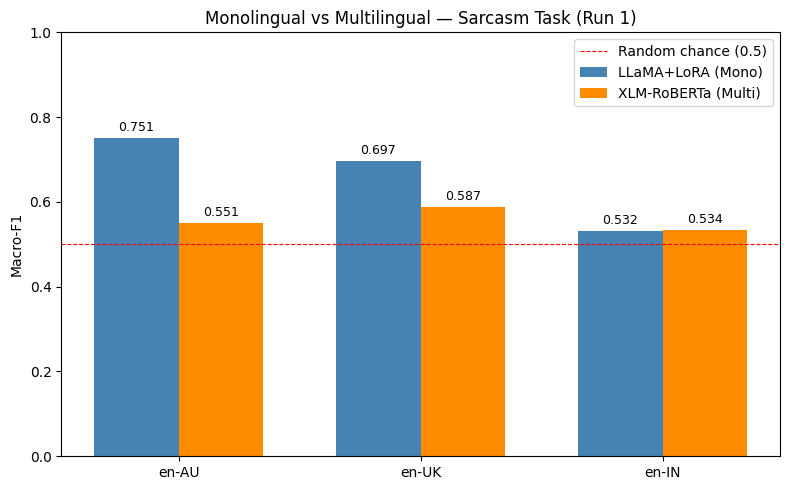

In [21]:
# quick chart for the report
varieties = ["en-AU", "en-UK", "en-IN"]
mono_scores = [adapter_scores_1[v][v] for v in varieties]
multi_scores = [xlm_scores_1[v] for v in varieties]

x = range(len(varieties))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
left_bars = ax.bar([i - bar_w / 2 for i in x], mono_scores, bar_w, label="LLaMA+LoRA (Mono)", color="steelblue")
right_bars = ax.bar([i + bar_w / 2 for i in x], multi_scores, bar_w, label="XLM-RoBERTa (Multi)", color="darkorange")

ax.bar_label(left_bars, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(right_bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(varieties)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Macro-F1")
ax.set_title("Monolingual vs Multilingual — Sarcasm Task (Run 1)")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Random chance (0.5)")
ax.legend()
plt.tight_layout()
plt.savefig("bar_mono_vs_multi.png", dpi=150)
plt.show()


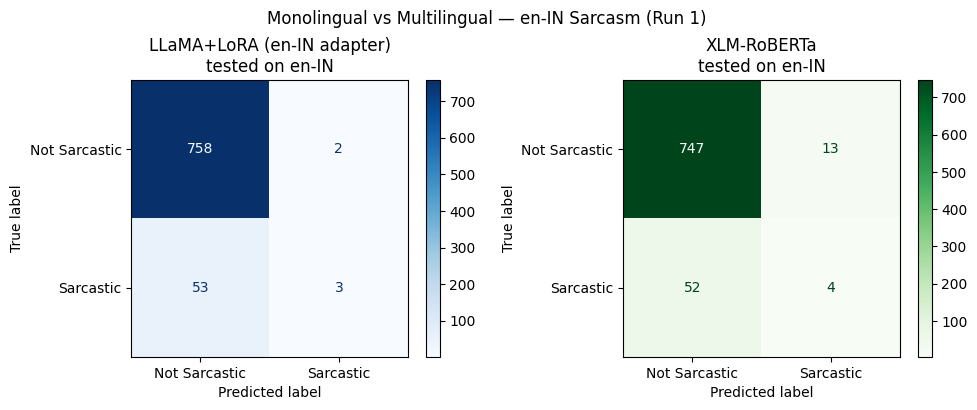

In [23]:
# confusion matrix from the stored reports
# mainly using this for the en-IN comparison slide/write-up

def report_to_cm(rep):
    ns_total = int(rep["Not Sarcastic"]["support"])
    s_total = int(rep["Sarcastic"]["support"])
    ns_hit = int(round(rep["Not Sarcastic"]["recall"] * ns_total))
    s_hit = int(round(rep["Sarcastic"]["recall"] * s_total))
    # return as numpy array so ConfusionMatrixDisplay is happy
    return np.array([[ns_hit, ns_total - ns_hit],
                     [s_total - s_hit, s_hit]])

rep_lora_in = adapter_reports_1["en-IN"]["en-IN"]
rep_xlm_in = xlm_reports_1["en-IN"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=report_to_cm(rep_lora_in),
    display_labels=["Not Sarcastic", "Sarcastic"],
).plot(cmap="Blues", ax=axes[0])
axes[0].set_title("LLaMA+LoRA (en-IN adapter)\ntested on en-IN")

ConfusionMatrixDisplay(
    confusion_matrix=report_to_cm(rep_xlm_in),
    display_labels=["Not Sarcastic", "Sarcastic"],
).plot(cmap="Greens", ax=axes[1])
axes[1].set_title("XLM-RoBERTa\ntested on en-IN")

plt.suptitle("Monolingual vs Multilingual — en-IN Sarcasm (Run 1)", fontsize=12)
plt.tight_layout()
plt.savefig("cm_mono_vs_multi_enIN.png", dpi=150)
plt.show()

In [24]:
# keep track of the best saved models for later parts
# but these folders should stay out of the final zip
print("best lora adapters")

for i in range(len(adapter_names)):
    name = adapter_names[i]
    run1_score = adapter_scores_1[name][name]
    run2_score = adapter_scores_2[name][name]

    if run1_score >= run2_score:
        print(name, "->", adapter_paths_1[i], "(run 1)")
    else:
        print(name, "->", adapter_paths_2[i], "(run 2)")

print()
print("best xlm path")
if xlm_scores_1["en-IN"] >= xlm_scores_2["en-IN"]:
    print(xlm_path_1)
else:
    print(xlm_path_2)



best lora adapters
en-AU -> adapter_en-AU_seed42 (run 1)
en-UK -> adapter_en-UK_seed1234 (run 2)
en-IN -> adapter_en-IN_seed42 (run 1)

best xlm path
xlm_roberta_seed_42
